# MWE: reconstructing an image from AMI-like data

An image fit in drpangloss is an ordinary `Problem` whose model contains an `Image`. The pixels' log-brightnesses get flat priors from `drpangloss.imaging.image_priors`, and a regulariser supplies the prior information that the sparse data cannot: here maximum entropy, which prefers images close to a flat default. The unresolved star stays an analytic `PointSource` at the origin, which also fixes the image's position, since the phase data are blind to shifts.

This notebook simulates AMI-like data from a known ring, reconstructs it, and checks the result with `drpangloss.imaging.diagnose`. You should come away able to set up an image fit and read its diagnostics.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from drpangloss.amigo import simulated_disco_record
from drpangloss.fitting import Problem, fit
from drpangloss.imaging import (
    MaxEntropy,
    diagnose,
    image_priors,
    nyquist_pixel_scale,
)
from drpangloss.likelihood import whitened_residuals
from drpangloss.models import GaussianDisk, Image, PointSource, System
from drpangloss.oidata import OIData
from drpangloss.plotting import plot_model
from drpangloss.scenes import ring

template = OIData(
    simulated_disco_record(wavelength_m=4.8e-6, rotation_deg=-6.9)
)
npix, scale = 32, 10.0
truth_image = ring(
    npix,
    scale,
    80.0,
    12.0,
    inc_deg=50.0,
    pa_deg=30.0,
    asymmetry=0.5,
    asymmetry_pa_deg=90.0,
)
truth = System(
    star=PointSource(), env=Image.from_brightness(truth_image, scale, flux=0.1)
)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
print(
    f"{data.vis.size} DISCO-like coefficients; pixels of {scale} mas, Nyquist {nyquist_pixel_scale(data):.0f} mas"
)

W0930 23:26:51.978797 9953393 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


314 DISCO-like coefficients; pixels of 10.0 mas, Nyquist 76 mas


## The fit

The fit starts from a blurred Gaussian with the right flux, a stand-in for a parametric fit. Maximum entropy has no least-squares form, so `fit` uses L-BFGS; the weight 300 comes from the L-curve in the next MWE. The fit takes a few seconds.

In [2]:
start = System(
    star=PointSource(),
    env=Image.from_model(GaussianDisk(60.0), npix, scale, flux=0.1),
)
problem = Problem(
    start, data, image_priors(start), [MaxEntropy(300.0, path="env")]
)
result = fit(problem)
info = result.info
print(
    f"{info['method']}: converged = {info['converged']} after {info['steps']} steps, chi2 per point {info['chi2_red']:.3f}"
)

lbfgs: converged = True after 12781 steps, chi2 per point 1.039


## Truth, start and reconstruction

The reconstruction recovers the inclined ring, its orientation, its brighter eastern side and even its narrow width, well below the ~150 mas fringe spacing of the longest baselines. That super-resolution comes from the high signal-to-noise ratio (errors of 1e-4 on a ring with 10% of the star's flux) together with the regulariser; at lower signal-to-noise it degrades, as the recovery-sweep MWE shows. The images are shown North up and East left.

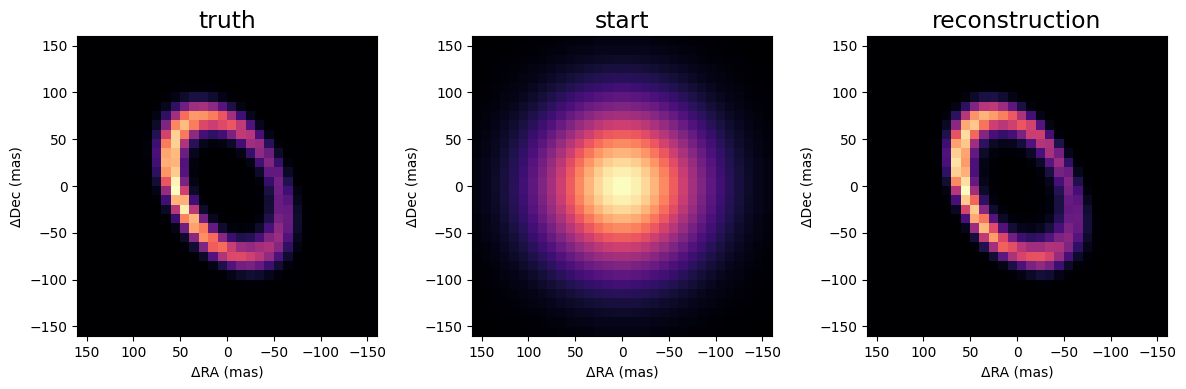

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, image, title in zip(
    axes,
    [truth.env, start.env, result.model.env],
    ["truth", "start", "reconstruction"],
):
    plot_model(image, fov_mas=npix * scale, npix=npix, ax=ax, title=title)
plt.tight_layout()
plt.show()

## Residuals

The whitened residuals (model minus data, in units of each coefficient's error) should look like unit-variance noise if the fit is good. The histogram is compared with a standard normal curve.

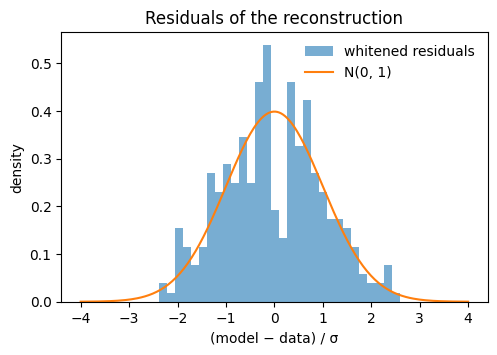

In [4]:
residuals = whitened_residuals(result.model, data)
x = jnp.linspace(-4, 4, 200)
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.hist(
    residuals, bins=30, density=True, alpha=0.6, label="whitened residuals"
)
ax.plot(x, jnp.exp(-0.5 * x**2) / jnp.sqrt(2 * jnp.pi), label="N(0, 1)")
ax.set(
    xlabel="(model − data) / σ",
    ylabel="density",
    title="Residuals of the reconstruction",
)
ax.legend(frameon=False)
plt.show()

## Diagnostics

`diagnose` runs a set of checks on the fitted model: χ² per point, whether the pixels are fine enough, how much flux sits at the edge of the field, what fixes the position, whether the data constrain the orientation (the change in χ² when the image is rotated by 180°), and whether the model visibilities stay in the regime where projected phases are reliable. It prints nothing but warnings about actual problems.

In [5]:
print(diagnose(result.model, data, problem.regularisers))

chi2_red         [1.04]
anchored         True
pixel_scale_mas  [10]
edge_flux        [6.85e-06]
centroid_mas     [[13.8, 4.94]]
flip_dchi2       1.52e+06
phase_regime     [0]

No warnings.


## Summary

Reconstructing an image takes a `System` with an analytic star and an `Image`, flat priors from `image_priors`, one regulariser and a call to `fit`. Here maximum entropy recovers the simulated ring with residuals consistent with the noise, and `diagnose` confirms that nothing obvious is wrong. How strong to make the regulariser, and which regulariser to use, are the subjects of the next two MWEs.